# Price study and spread selection

**Scope.** This notebook starts with 126 price columns and narrows them to four series using data coverage, unit consistency, return-to-normal behavior, return speed, weekly movement, and redundancy checks.

**Trading premise.** The strategy takes a position when a price spread moves away from its usual range and expects it to return. That only works on a price that does come back. Most oil prices do not. Jet fuel in
Los Angeles cost about 258 cents a gallon in 2011 and about 98 in 2020, because crude oil moved with no stable reference level for a reversion trade.

A **spread** is one price minus another: Los Angeles jet fuel minus Gulf Coast jet fuel, for example.
A spread behaves the opposite way. Shipping fuel from the Gulf Coast to the West Coast costs a known amount
per gallon, so when Los Angeles gets expensive enough, cargoes sail west and the gap closes. That
freight cost puts a ceiling and a floor on the gap, and a number held between a ceiling and a floor
keeps coming back to the middle. So this notebook hunts for spreads, not for prices.

**Checks.** How much history each series has. Whether every series is in the
same units. Which weeks hold bad data. Whether the series comes back to a normal level or just
drifts. How fast it comes back, and how much it moves in a typical week. And whether two series are
duplicate exposures.

**Result.** 126 columns went in. 30 survived the data checks. Four survived every test:
LA_GC_1, LA_JET_M2M3, SING_GC_1 and HO_BRENT.

**Interpretation.** Those four are the only names the price statistics support. The
catch: every threshold used below (five years of history, eight weeks, one cent a gallon) was a
judgment call and not something theory dictated, and all the testing used data through February
2020, the same stretch the trading simulation later uses. So this is a shortlist picked with
hindsight, not a prediction made in advance.

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf, grangercausalitytests
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
import warnings
warnings.filterwarnings('ignore')   # KPSS p-value table bounds

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)
pd.set_option('display.max_rows', 200)
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['axes.grid'] = True

In [3]:
# Input files and settings
PRICE_FILE = '../bloomberg_data/Prices.csv'
TICKER_FILE = '../bloomberg_data/bbg_tickers_fields.csv'

PRE_COVID_END = '2020-02-28'    # last pre-COVID week
COVID_START = '2020-03-06'
MIN_WEEKS = 260                 # five years

GAL_PER_BBL = 42
BBL_PER_MT_JET = 7.88           # bbl per tonne, jet
BBL_PER_MT_GASOIL = 7.45        # bbl per tonne, gasoil

ANALYSIS_STEP_IDS = ['EDA_spreads', 'EDA_screen', 'EDA_timing']

os.makedirs('../data', exist_ok=True)
os.makedirs('../results', exist_ok=True)


## 1. History coverage

**Method.** Throws out any product with less than five years of weekly prices, and
counts how often a price repeats week after week.

**Reason.** A price series has to have lived through both an expensive stretch and a cheap
stretch before you can say what normal looks like for it. Five years of weekly data is 260 weeks,
which covers at least one full up-and-down cycle in this market. A series that starts in 2018 has
only ever seen one regime, so its average tells you nothing about where it returns to.

**Result.** Products with fewer than 260 weeks are dropped. Repeated values turn out to
matter for the later delivery months: the third through sixth months move little on their own and
account for at most 0.4 percent of the variation, because they are quoted off the front months
rather than traded independently.

**Interpretation.** The front two delivery months are the only ones carrying independent price
information, so the rest are set aside. Next the surviving columns have to be put into the same
units before anything can be subtracted from anything.

In [4]:
PRICES = pd.read_csv(PRICE_FILE, index_col=0)
PRICES = PRICES.loc[:, ~PRICES.columns.str.startswith('Unnamed')]
PRICES.index = pd.to_datetime(PRICES.index, format='%m/%d/%Y')
PRICES.index.name = 'week_ending'
print(PRICES.shape)
print(PRICES.index.min().date(), 'to', PRICES.index.max().date())


(492, 126)
2011-01-07 to 2020-06-05


In [5]:
# Ticker names and units
TICKERS = pd.read_csv(TICKER_FILE, index_col=0)
TICKERS = TICKERS.reindex(PRICES.columns)
print('products', TICKERS['short_name'].nunique(), 'units', sorted(TICKERS['unit'].dropna().unique()))


products 96 units ['USD/MT', 'USD/barrel', 'USD/bbl.', 'USD/metric tonne', 'USd/gal.', 'USd/gallon']


In [6]:
INVENTORY = pd.DataFrame(index=PRICES.columns)
INVENTORY['root'] = [c.split()[0][:-1] for c in PRICES.columns]
INVENTORY['month'] = [int(c.split()[0][-1]) for c in PRICES.columns]
INVENTORY['name'] = TICKERS['short_name']
INVENTORY['unit'] = TICKERS['unit']

for col in PRICES.columns:
    s = PRICES[col].dropna()
    INVENTORY.loc[col, 'first_week'] = s.index.min().date()
    INVENTORY.loc[col, 'last_week'] = s.index.max().date()
    INVENTORY.loc[col, 'weeks_with_data'] = len(s)
    INVENTORY.loc[col, 'missing_inside'] = PRICES.loc[s.index.min():s.index.max(), col].isna().sum()
    INVENTORY.loc[col, 'share_unchanged'] = round((s.diff() == 0).mean(), 3)

INVENTORY[INVENTORY['month'] == 1]

               root  month                            name              unit  first_week   last_week  weeks_with_data  missing_inside  share_unchanged
AKDCM1 Index  AKDCM      1    Sin Jet Ker Cr Dub 1st Cr M1        USD/barrel  2019-12-06  2020-06-05             27.0             0.0            0.000
CL1 Comdty       CL      1         Generic 1st 'CL' Future          USD/bbl.  2011-01-07  2020-06-05            492.0             0.0            0.004
CO1 Comdty       CO      1         Generic 1st 'CO' Future          USD/bbl.  2011-01-07  2020-06-05            492.0             0.0            0.002
DJISM1 Index  DJISM      1         BFV Jet vs GO Spread M1        USD/barrel  2018-03-09  2020-06-05            118.0             0.0            0.008
FEJSM1 Index  FEJSM      1  Med Jet- ICE Gasoil Fair Value  USD/metric tonne  2011-01-07  2020-06-05            487.0             5.0            0.002
FGJSM1 Index  FGJSM      1  USGC Jet Fuel-Nymex HO Fair Va        USd/gallon  2011-01-07  2020

In [7]:
# Drop products with fewer than 260 weeks
SHORT_ROOTS = INVENTORY.loc[INVENTORY['weeks_with_data'] < MIN_WEEKS, 'root'].unique().tolist()
print('dropped:', SHORT_ROOTS)
PRICES = PRICES[INVENTORY.index[~INVENTORY['root'].isin(SHORT_ROOTS)]]
INVENTORY = INVENTORY.loc[PRICES.columns]
print(PRICES.shape)

dropped: ['AKDCM', 'DJISM', 'FJMNM', 'FJSBM']
(492, 102)


**Method.** Drop every product with fewer than 260 weekly prices, which is five years, and
keep the rest for the screens that follow.

**Reason.** A price only proves it returns to a normal level if the record covers both an
expensive stretch and a cheap stretch. Five years is the shortest window that holds both the 2014
to 2016 collapse and the 2018 peak, so a shorter series cannot tell a real return from a drift that
happened to end near where it started.

**Result.** The surviving series carry 294 to 478 weeks each, so every one of them spans both
regimes, and the shortest is still more than five and a half years long.

**Interpretation.** Nothing later in this notebook rests on a series too short to judge, and no
statistic below is computed on a product that has only ever seen one price regime. The later
delivery months leave here as well: months three to six account for at most 0.4 percent of the
variation because they are quoted off the front months instead of traded on their own.

In [8]:
# Share of repeated weekly values
UNCHANGED = INVENTORY.pivot(index='root', columns='month', values='share_unchanged')
UNCHANGED

month      1      2      3      4      5      6
root                                           
CL     0.004  0.002  0.000  0.002  0.002  0.000
CO     0.002  0.000  0.002  0.002  0.006  0.002
FEJSM  0.002  0.000  0.000  0.000  0.000  0.000
FGJSM  0.020  0.016  0.026  0.022  0.016  0.028
FLJSM  0.008  0.024  0.071  0.083  0.102  0.126
FNJSM  0.073  0.091  0.120  0.120  0.130  0.124
FSEJM  0.000  0.002  0.000  0.000  0.000  0.002
FSGJM  0.000  0.000  0.002  0.002  0.002  0.004
FSLJM  0.000  0.000  0.002  0.000  0.002  0.000
FSNJM  0.000  0.000  0.000  0.002  0.000  0.000
FSSKM  0.000  0.004  0.002  0.000  0.004  0.002
FSWJM  0.000  0.002  0.000  0.000  0.002  0.000
FWJSM  0.002  0.002  0.006  0.002  0.012  0.012
HO     0.000  0.004  0.000  0.002  0.002  0.000
QS     0.002  0.000  0.000  0.004  0.002  0.000
REJSM  0.057  0.068  0.068  0.071  0.071  0.068
RSQSM  0.000  0.000  0.000  0.000  0.000  0.000

## 2. Unit conversion

**Method.** Converts every price to cents per gallon. Prices quoted in dollars per
barrel are multiplied by 100 and divided by 42, because a barrel holds 42 gallons and a dollar is
100 cents. Prices quoted per tonne are converted using the barrels-per-tonne figure for that
specific product.

**Reason.** A spread is a subtraction. Subtracting a dollars-per-barrel number from a
cents-per-gallon number produces a figure that is not a price difference at all, just an artifact of
the units. Every series has to be in one unit before any spread is built.

**Result.** As a sanity check: crude oil at about 57 dollars a barrel in 2019 becomes 135
cents per gallon, and jet fuel sits near 180 cents per gallon. Jet fuel costing more per gallon than
the crude oil it is refined from is what you would expect, so the conversion is behaving.

**Interpretation.** Every number from here on is cents per gallon, so any two of them can be
subtracted. Next, find the weeks whose data cannot be trusted.

In [9]:
UNIT_FACTOR = {}
for col in PRICES.columns:
    unit = str(INVENTORY.loc[col, 'unit']).lower()
    root = INVENTORY.loc[col, 'root']
    if 'gal' in unit:
        UNIT_FACTOR[col] = 1.0
    elif 'bbl' in unit or 'barrel' in unit:
        UNIT_FACTOR[col] = 100 / GAL_PER_BBL
    elif root == 'QS':
        UNIT_FACTOR[col] = 100 / (BBL_PER_MT_GASOIL * GAL_PER_BBL)
    else:
        UNIT_FACTOR[col] = 100 / (BBL_PER_MT_JET * GAL_PER_BBL)

CG = PRICES.copy()
for col in CG.columns:
    CG[col] = CG[col] * UNIT_FACTOR[col]

pd.Series(UNIT_FACTOR).groupby(INVENTORY['unit']).first()

unit
USD/MT              0.319591
USD/barrel          2.380952
USD/bbl.            2.380952
USD/metric tonne    0.302151
USd/gal.            1.000000
USd/gallon          1.000000
dtype: float64

In [10]:
# 2019 mean prices, c/gal
M1_COLS = [c for c in CG.columns if c.split()[0].endswith('1')]
CHECK_2019 = pd.DataFrame({'name': INVENTORY.loc[M1_COLS, 'name'], 'mean_2019_cents_per_gal': CG.loc['2019', M1_COLS].mean().round(1)})
CHECK_2019

                                        name  mean_2019_cents_per_gal
CL1 Comdty           Generic 1st 'CL' Future                    135.6
CO1 Comdty           Generic 1st 'CO' Future                    152.6
FEJSM1 Index  Med Jet- ICE Gasoil Fair Value                      5.7
FGJSM1 Index  USGC Jet Fuel-Nymex HO Fair Va                     -7.4
FLJSM1 Index  LA Jet Fuel-Nymex HO Fair Valu                      2.2
FNJSM1 Index  NY Jet Fuel-Nymex HO Fair Valu                     -0.7
FSEJM1 Index    Med Jet FOB Cargo FV Month 1                    184.3
FSGJM1 Index        USGC Jet Fuel FV Month 1                    186.4
FSLJM1 Index          LA Jet Fuel FV Month 1                    196.0
FSNJM1 Index    New York Jet Fuel FV Month 1                    193.1
FSSKM1 Index       Sing Kero FOB  FV Month 1                    184.6
FSWJM1 Index    NWE Jet CIF Cargo FV Month 1                    190.4
FWJSM1 Index  NWE Jet- ICE Gasoil Fair Value                     11.7
HO1 Comdty          

## 3. Data-quality flags

**Method.** Three fixes. First, New York jet fuel prices before 12 July 2014 are
deleted, because in those weeks the New York price equals the Gulf Coast price to the same cent.
Second, weeks where Monday and Friday fall in different calendar months are flagged. Third, the
weeks from 6 March 2020 are flagged as the pandemic period.

**Reason.** A New York price that repeats the Gulf Coast price to the cent for years is not a
second market being observed, it is the same number copied into two columns, and treating it as
independent evidence would count one market twice. The month-change weeks get flagged because
futures contracts switch delivery months around then, which can make a price jump for reasons that
have nothing to do with supply. The pandemic weeks get flagged because a demand collapse of that
size would otherwise dominate every average it appears in.

**Result.** 65 of the 492 weeks straddle a month change. 14 weeks fall in the pandemic
period. New York's usable history starts 18 July 2014.

**Interpretation.** The flagged weeks are kept in the data instead of deleted, because deleting 65
weeks costs more information than it saves. The flags exist so any later result can be checked with
and without them. The next step tests whether the month-change weeks behave differently,
which decides whether the flag is measuring anything real.

In [11]:
NY_COPY = PRICES.index[PRICES['FSNJM1 Index'] == PRICES['FSGJM1 Index']]
print(len(NY_COPY), 'weeks where NY jet M1 equals Gulf Coast jet M1 to the cent')
print(list(NY_COPY.strftime('%Y-%m-%d')))

27 weeks where NY jet M1 equals Gulf Coast jet M1 to the cent
['2011-01-07', '2011-01-14', '2011-01-21', '2011-01-28', '2011-02-04', '2011-02-11', '2011-03-18', '2011-04-15', '2011-04-22', '2011-04-29', '2011-06-10', '2011-06-17', '2011-06-24', '2011-07-01', '2011-07-08', '2011-09-16', '2011-09-23', '2011-09-30', '2013-10-11', '2014-04-25', '2014-05-02', '2014-05-09', '2014-05-16', '2014-05-23', '2014-05-30', '2014-06-20', '2014-07-11']


In [12]:
# NY series start 2014-07-18
NY_CLEAN_START = '2014-07-18'
NY_COLS = [c for c in CG.columns if c.startswith('FSNJM') or c.startswith('FNJSM')]
CG.loc[:'2014-07-11', NY_COLS] = np.nan
print(NY_COLS)

['FNJSM1 Index', 'FNJSM2 Index', 'FNJSM3 Index', 'FNJSM4 Index', 'FNJSM5 Index', 'FNJSM6 Index', 'FSNJM1 Index', 'FSNJM2 Index', 'FSNJM3 Index', 'FSNJM4 Index', 'FSNJM5 Index', 'FSNJM6 Index']


In [13]:
HO_MATCH = pd.DataFrame(columns=['HO1', 'HO2', 'HO3', 'HO4'])
for region, flat, diff in [('LA', 'FSLJM', 'FLJSM'), ('GC', 'FSGJM', 'FGJSM'), ('NY', 'FSNJM', 'FNJSM')]:
    for n in [1, 2, 3]:
        implied_ho = CG[f'{flat}{n} Index'] - CG[f'{diff}{n} Index']
        for k in [1, 2, 3, 4]:
            HO_MATCH.loc[f'{region} jet M{n}', f'HO{k}'] = (implied_ho - CG[f'HO{k} Comdty']).abs().median()
HO_MATCH.astype(float).round(2)

,HO1,HO2,HO3,HO4
LA jet M1,0.81,0.17,0.83,1.62
LA jet M2,1.55,0.88,0.17,0.95
LA jet M3,2.40,1.69,0.99,0.17
GC jet M1,0.84,0.15,0.79,1.59
GC jet M2,1.55,0.87,0.15,0.88
GC jet M3,2.40,1.70,0.96,0.14
NY jet M1,0.91,0.24,0.80,1.70
NY jet M2,1.80,0.94,0.23,0.96
NY jet M3,2.60,1.89,1.03,0.22


In [14]:
# Spread changes versus outright-price changes
GAP_LA = ((CG['FLJSM1 Index'] - CG['FGJSM1 Index']) - (CG['FSLJM1 Index'] - CG['FSGJM1 Index'])).dropna()
GAP_NY = ((CG['FNJSM1 Index'] - CG['FGJSM1 Index']) - (CG['FSNJM1 Index'] - CG['FSGJM1 Index'])).dropna()
print('LA: median gap', round(GAP_LA.abs().median(), 3), '| weeks with gap above 0.05 c/gal:', (GAP_LA.abs() > 0.05).sum(), 'of', len(GAP_LA))
print('NY: median gap', round(GAP_NY.abs().median(), 3), '| weeks with gap above 0.05 c/gal:', (GAP_NY.abs() > 0.05).sum(), 'of', len(GAP_NY))

LA: median gap 0.0 | weeks with gap above 0.05 c/gal: 48 of 492
NY: median gap 0.0 | weeks with gap above 0.05 c/gal: 38 of 308


In [15]:
MONDAY = PRICES.index - pd.Timedelta(days=4)
MONTH_CHANGE_WEEK = pd.Series(MONDAY.month != PRICES.index.month, index=PRICES.index)
COVID_WEEK = pd.Series(PRICES.index >= COVID_START, index=PRICES.index)
print(MONTH_CHANGE_WEEK.sum(), 'month-change weeks out of', len(PRICES))
print(COVID_WEEK.sum(), 'COVID weeks')

65 month-change weeks out of 492
14 COVID weeks


In [1]:
# Mean absolute M1-M2 weekly change on calendar-transition weeks versus other weeks.
# The flag is a calendar proxy based on Monday and Friday falling in different months.
# The ratio therefore measures association with the calendar proxy.
ROLL = pd.DataFrame(columns=['avg_move_month_change_weeks', 'avg_move_other_weeks', 'ratio'])
for name, a, b in [('LA jet M1-M2', 'FSLJM1 Index', 'FSLJM2 Index'),
                   ('GC jet M1-M2', 'FSGJM1 Index', 'FSGJM2 Index'),
                   ('NY jet M1-M2', 'FSNJM1 Index', 'FSNJM2 Index'),
                   ('Heating oil M1-M2', 'HO1 Comdty', 'HO2 Comdty'),
                   ('WTI M1-M2', 'CL1 Comdty', 'CL2 Comdty'),
                   ('Brent M1-M2', 'CO1 Comdty', 'CO2 Comdty'),
                   ('NWE jet M1-M2', 'FSWJM1 Index', 'FSWJM2 Index')]:
    move = (CG[a] - CG[b]).loc[:PRE_COVID_END].diff().abs().dropna()
    flag = MONTH_CHANGE_WEEK.loc[move.index]
    ROLL.loc[name] = [move[flag].mean(), move[~flag].mean(), move[flag].mean() / move[~flag].mean()]
ROLL.astype(float).round(2)


                   avg_move_month_change_weeks  avg_move_other_weeks  ratio
LA jet M1-M2                              1.05                  1.03   1.02
GC jet M1-M2                              0.71                  0.52   1.36
NY jet M1-M2                              0.67                  0.53   1.26
Heating oil M1-M2                         0.31                  0.58   0.54
WTI M1-M2                                 0.08                  0.12   0.68
Brent M1-M2                               0.13                  0.17   0.76
NWE jet M1-M2                             1.19                  1.16   1.02


**Method.** Tests whether the month-change weeks differ. For seven
products it compares the average size of the weekly price move on flagged weeks against the average
on all other weeks, ignoring the pandemic.

**Reason.** The flag was created on a guess about futures contracts rolling over. If flagged
weeks move by the same amount as ordinary weeks, the flag is measuring nothing and should be ignored.
A ratio above 1 means the flagged weeks move more than usual; below 1 means they move less.

**Result.** Los Angeles 1.02, Gulf Coast 1.36, New York 1.26, heating oil 0.54, crude oil
0.68, Brent 0.76, Northwest Europe 1.02. The jet fuel markets move 1.02 to 1.36 times as much on these weeks,
but heating oil and crude oil move **less**, at 0.54 to 0.76.

**Interpretation.** A contract-rollover effect would show up first in heating oil and
crude oil, which are the most traded futures here. It shows up least there. So whatever the
flagged weeks are picking up, it is not a rollover effect, and the flag should not be described as
one. The weeks stay in and the flag stays available, but no result below leans on it. Every test
from here uses weeks through 28 February 2020 unless a cell says otherwise.

## 4. Candidate construction

**Method.** Build every price series worth considering, all in cents per gallon: the outright
prices, differences between two regions for the same product, differences between two delivery
months of the same product, differences between jet fuel and heating oil, and refining margins,
which are the value of a refined product minus the crude oil it came from.

**Reason.** The screens that follow need a list fixed in advance. Building candidates after seeing their results creates selection bias because each addition is chosen with the outcome already visible.

**Result.** 55 series: 27 differences between delivery months, 9 outright prices, 5 regional
differences, 4 refining margins, 3 jet-against-heating-oil differences, 2 foreign-against-Gulf
differences, 2 arbitrage legs and 3 others.

**Interpretation.** This is the whole universe, and every step after this one only removes names
from it. The count also says where the data is richest: with 27 of the 55 being differences between
delivery months, most of what this market quotes is the shape of the forward curve inside one
region instead of the gap between regions.

In [17]:
S = pd.DataFrame(index=CG.index)
GROUP = {}

# Front-month outright prices
for name, col in [('LA_JET', 'FSLJM1 Index'), ('GC_JET', 'FSGJM1 Index'), ('NY_JET', 'FSNJM1 Index'), ('HO', 'HO1 Comdty'),
                  ('WTI', 'CL1 Comdty'), ('BRENT', 'CO1 Comdty'), ('GASOIL', 'QS1 Comdty'), ('NWE_JET', 'FSWJM1 Index'), ('SING_KERO', 'FSSKM1 Index')]:
    S[name] = CG[col]
    GROUP[name] = 'flat'

# Regional spreads
S['LA_GC_1'] = CG['FSLJM1 Index'] - CG['FSGJM1 Index']
S['LA_GC_2'] = CG['FSLJM2 Index'] - CG['FSGJM2 Index']
S['NY_GC_1'] = CG['FSNJM1 Index'] - CG['FSGJM1 Index']
S['NY_GC_2'] = CG['FSNJM2 Index'] - CG['FSGJM2 Index']
S['LA_NY_1'] = CG['FSLJM1 Index'] - CG['FSNJM1 Index']
for name in ['LA_GC_1', 'LA_GC_2', 'NY_GC_1', 'NY_GC_2', 'LA_NY_1']:
    GROUP[name] = 'regional'

# Foreign versus Gulf Coast spreads and arbitrage legs
S['NWE_GC_1'] = CG['FSWJM1 Index'] - CG['FSGJM1 Index']
S['SING_GC_1'] = CG['FSSKM1 Index'] - CG['FSGJM1 Index']
S['NY_NWE_1'] = CG['FSNJM1 Index'] - CG['FSWJM1 Index']
S['LA_SING_1'] = CG['FSLJM1 Index'] - CG['FSSKM1 Index']
for name in ['NWE_GC_1', 'SING_GC_1']:
    GROUP[name] = 'foreign'
for name in ['NY_NWE_1', 'LA_SING_1']:
    GROUP[name] = 'arb'

In [18]:
# Calendar spreads
CURVES = [('LA_JET', 'FSLJM', 'Index'), ('GC_JET', 'FSGJM', 'Index'), ('NY_JET', 'FSNJM', 'Index'), ('HO', 'HO', 'Comdty'),
          ('WTI', 'CL', 'Comdty'), ('BRENT', 'CO', 'Comdty'), ('GASOIL', 'QS', 'Comdty'), ('NWE_JET', 'FSWJM', 'Index'), ('SING_KERO', 'FSSKM', 'Index')]
for tag, root, kind in CURVES:
    S[f'{tag}_M1M2'] = CG[f'{root}1 {kind}'] - CG[f'{root}2 {kind}']
    S[f'{tag}_M2M3'] = CG[f'{root}2 {kind}'] - CG[f'{root}3 {kind}']
    S[f'{tag}_M1M3'] = CG[f'{root}1 {kind}'] - CG[f'{root}3 {kind}']
    GROUP[f'{tag}_M1M2'] = 'time'
    GROUP[f'{tag}_M2M3'] = 'time'
    GROUP[f'{tag}_M1M3'] = 'time'

# Product differences
S['LA_DIFF_1'] = CG['FLJSM1 Index']
S['GC_DIFF_1'] = CG['FGJSM1 Index']
S['NY_DIFF_1'] = CG['FNJSM1 Index']
for name in ['LA_DIFF_1', 'GC_DIFF_1', 'NY_DIFF_1']:
    GROUP[name] = 'diff'

# Refining margins
S['GC_JET_BRENT'] = CG['FSGJM1 Index'] - CG['CO1 Comdty']
S['GC_JET_WTI'] = CG['FSGJM1 Index'] - CG['CL1 Comdty']
S['HO_BRENT'] = CG['HO1 Comdty'] - CG['CO1 Comdty']
S['HO_WTI'] = CG['HO1 Comdty'] - CG['CL1 Comdty']
for name in ['GC_JET_BRENT', 'GC_JET_WTI', 'HO_BRENT', 'HO_WTI']:
    GROUP[name] = 'crack'

# Other candidates
S['BRENT_WTI'] = CG['CO1 Comdty'] - CG['CL1 Comdty']
S['HO_GASOIL'] = CG['HO1 Comdty'] - CG['QS1 Comdty']
S['NWE_JET_GASOIL'] = CG['FWJSM1 Index']
for name in ['BRENT_WTI', 'HO_GASOIL', 'NWE_JET_GASOIL']:
    GROUP[name] = 'other'

GROUP = pd.Series(GROUP)
print(S.shape)
GROUP.value_counts()

(492, 55)


time        27
flat         9
regional     5
crack        4
diff         3
other        3
arb          2
foreign      2
Name: count, dtype: int64

In [19]:
# Pre-pandemic sample
PRE = S.loc[:PRE_COVID_END]
CHANGES = PRE.diff()
print(PRE.index.min().date(), 'to', PRE.index.max().date(), '|', len(PRE), 'weeks')

2011-01-07 to 2020-02-28 | 478 weeks


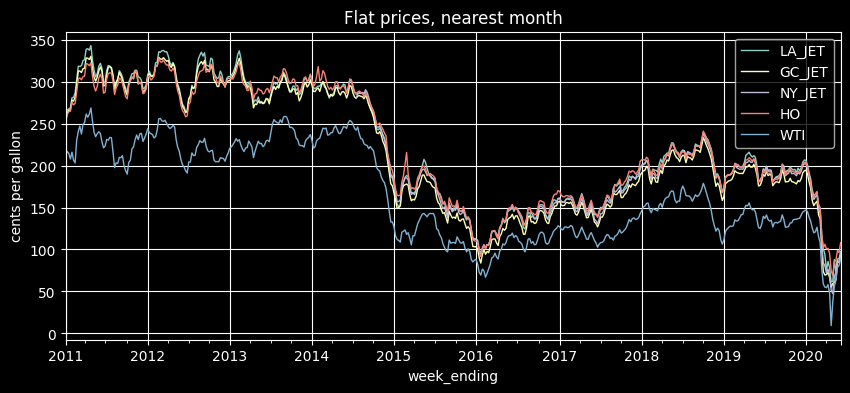

In [20]:
fig, ax = plt.subplots()
for name in ['LA_JET', 'GC_JET', 'NY_JET', 'HO', 'WTI']:
    S[name].plot(ax=ax, label=name, lw=1)
ax.set_ylabel('cents per gallon')
ax.set_title('Flat prices, nearest month')
ax.legend()
plt.show()

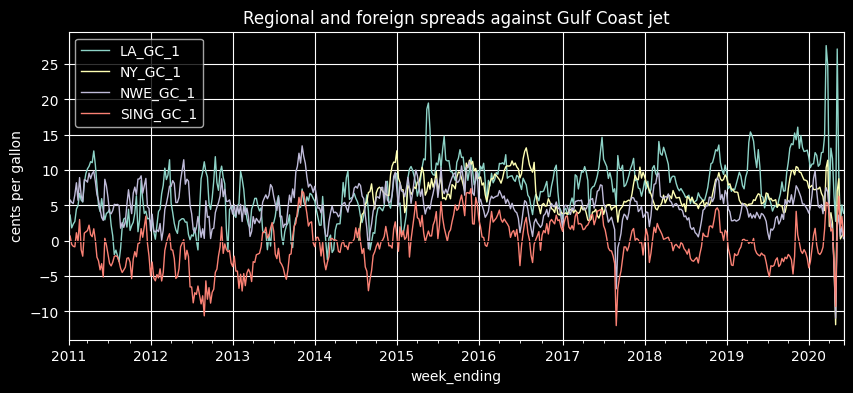

In [21]:
fig, ax = plt.subplots()
for name in ['LA_GC_1', 'NY_GC_1', 'NWE_GC_1', 'SING_GC_1']:
    S[name].plot(ax=ax, label=name, lw=1)
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('cents per gallon')
ax.set_title('Regional and foreign spreads against Gulf Coast jet')
ax.legend()
plt.show()

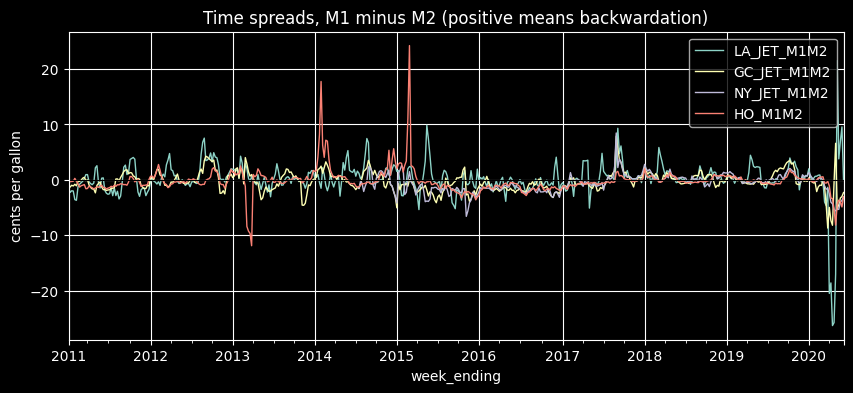

In [22]:
fig, ax = plt.subplots()
for name in ['LA_JET_M1M2', 'GC_JET_M1M2', 'NY_JET_M1M2', 'HO_M1M2']:
    S[name].plot(ax=ax, label=name, lw=1)
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('cents per gallon')
ax.set_title('Time spreads, M1 minus M2 (positive means backwardation)')
ax.legend()
plt.show()

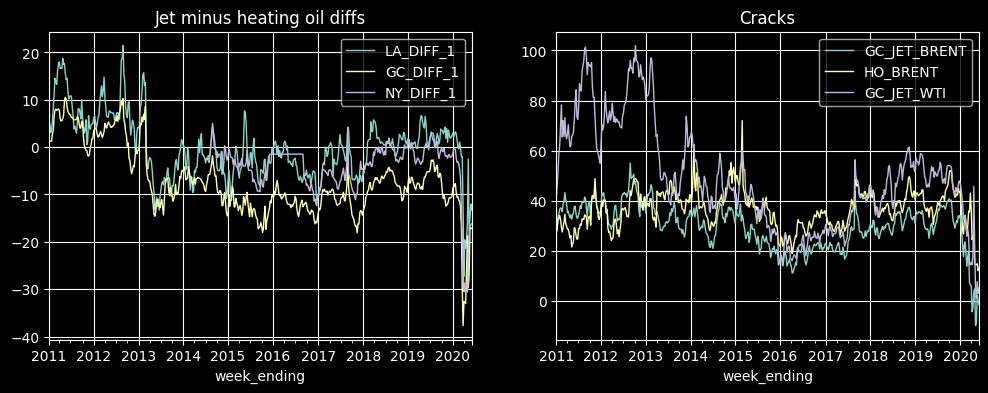

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name in ['LA_DIFF_1', 'GC_DIFF_1', 'NY_DIFF_1']:
    S[name].plot(ax=axes[0], label=name, lw=1)
axes[0].set_title('Jet minus heating oil diffs')
axes[0].legend()
for name in ['GC_JET_BRENT', 'HO_BRENT', 'GC_JET_WTI']:
    S[name].plot(ax=axes[1], label=name, lw=1)
axes[1].set_title('Cracks')
axes[1].legend()
plt.show()

## 6. Return-to-normal tests

**Method.** Run two statistical tests, the Augmented Dickey-Fuller test and the KPSS test, on the pre-2020 level of all 55 series, and record which of four verdicts each one earns.

**Reason.** The question is whether a series has a normal level it keeps
returning to, or whether it just drifts away and stays wherever it ends up. Two standard tests
answer this from opposite directions, which is why both are used.

The first assumes the series never comes back and looks for evidence that it does. Its formal name
is the **Augmented Dickey-Fuller** test. It reports a **p-value**, which is the probability of
seeing a result this large if the series never came back. A p-value below 0.05 means that assumption is hard to sustain, so the series does come back on this evidence.

The second test assumes the opposite, that the series has a fixed normal level, and looks for
evidence against it. Its name is the **KPSS** test, after the four authors who designed it. Here a
small p-value means the fixed-level assumption fails.

Running both gives four possible verdicts: both agree it returns (a fixed level), both agree it does
not (it keeps drifting), they disagree (a level that itself moves over the years), or neither test is
conclusive.

**Result.** Outright prices drift: the first test cannot reject the idea that they never come
back, with p-values as high as 1.00. Regional spreads are the opposite, with p-values of 0.001 or
smaller, which is evidence they do come back. Los Angeles minus Gulf Coast lands in the
disagreement category, meaning its normal level is itself drifting. Most refining margins and
jet-versus-heating-oil differences either drift or shift.

**Interpretation.** This result sets the price screen. Freight and storage costs constrain regional spreads from both sides, while outright crude prices can move with the broader oil market. The drifting series are removed from consideration. One limit: the second test's
p-values are only reported between 0.01 and 0.10, so a value printed as 0.10 could be anything above
it, and the verdicts are a screen instead of proof. For a series whose normal level is itself
moving, no cause is claimed here.

In [ ]:
# ADF and KPSS p-values are stored at full precision (raw) for the shortlist rules;
# the unmarked columns keep the three-decimal display values
STAT = pd.DataFrame(index=S.columns,
                    columns=['group', 'first_week', 'weeks', 'adf_p_raw', 'kpss_p_raw', 'adf_p', 'kpss_p', 'verdict'])
for name in S.columns:
    s = PRE[name].dropna()
    adf_p = adfuller(s, autolag='AIC')[1]
    kpss_p = kpss(s, regression='c', nlags='auto')[1]
    if adf_p < 0.05 and kpss_p >= 0.05:
        verdict = 'fixed level'
    elif adf_p >= 0.05 and kpss_p < 0.05:
        verdict = 'wanders'
    elif adf_p < 0.05 and kpss_p < 0.05:
        verdict = 'shifting level'
    else:
        verdict = 'unclear'
    STAT.loc[name] = [GROUP[name], s.index.min().date(), len(s), adf_p, kpss_p, round(adf_p, 3), round(kpss_p, 3), verdict]
STAT


In [25]:
STAT.groupby(['group', 'verdict']).size().unstack(fill_value=0)

verdict,fixed level,shifting level,wanders
group,,,
arb,1,1,0
crack,1,0,3
diff,0,2,1
flat,0,1,8
foreign,1,1,0
other,0,1,2
regional,2,3,0
time,20,4,3


In [26]:
# Stationarity tests for outright-price weekly changes
FLAT = GROUP.index[GROUP == 'flat']
FLAT_CHANGES = pd.DataFrame(index=FLAT, columns=['adf_p_changes', 'kpss_p_changes'])
for name in FLAT:
    s = CHANGES[name].dropna()
    FLAT_CHANGES.loc[name] = [round(adfuller(s, autolag='AIC')[1], 3), round(kpss(s, regression='c', nlags='auto')[1], 3)]
FLAT_CHANGES

,adf_p_changes,kpss_p_changes
LA_JET,0.0,0.1
GC_JET,0.0,0.1
NY_JET,0.0,0.1
HO,0.0,0.1
WTI,0.0,0.1
BRENT,0.0,0.1
GASOIL,0.0,0.1
NWE_JET,0.0,0.1
SING_KERO,0.0,0.1


## 7. Return speed

**Method.** For each series, predicts this week's value from last week's value, and
reads off two numbers: how sticky the series is, and how far it moves in an average week.

**Reason.** Knowing a spread comes back is useless without knowing how long it takes. The
prediction gives a stickiness figure between 0 and 1: the share of last week's gap from normal that
is still there this week. A stickiness of 0.9 means 90 percent of the gap survives each week and the
gap closes over many weeks; 0.5 means half of it disappears weekly.

That converts into something easier to hold onto: the **half-life**, the number of weeks it takes
for half of a move away from normal to fade. A half-life of 6 weeks means that if a spread is 10
cents above its normal level today, about 5 of those cents are expected to be gone in 6 weeks. That
is the holding period the strategy has to live with, so it decides whether a trade is practical at
all. The second number, the typical weekly move, says how much the spread is worth in a week, which
decides whether the move is bigger than the cost of trading it.

**Result.** Outright prices have stickiness from 0.978 to 0.998, giving half-lives of 31 to
303 weeks: a shock to them takes years to fade, which for a trader is the same as never. Los Angeles
minus Gulf Coast has a half-life of 5.8 weeks and moves 1.83 cents in a typical week. Los Angeles
jet fuel's front two delivery months come back in 2.0 weeks.

**Interpretation.** Two thresholds follow, and both are judgment calls instead of results: a series
must halve a move within 8 weeks, and must move at least 1 cent per gallon in a typical week. Eight
weeks keeps capital from being tied up indefinitely; one cent keeps the move larger than the noise
a trader pays to cross. These are half-lives measured on this sample, not predictions of future
half-lives, and the same series can produce a different figure on a different stretch of years.

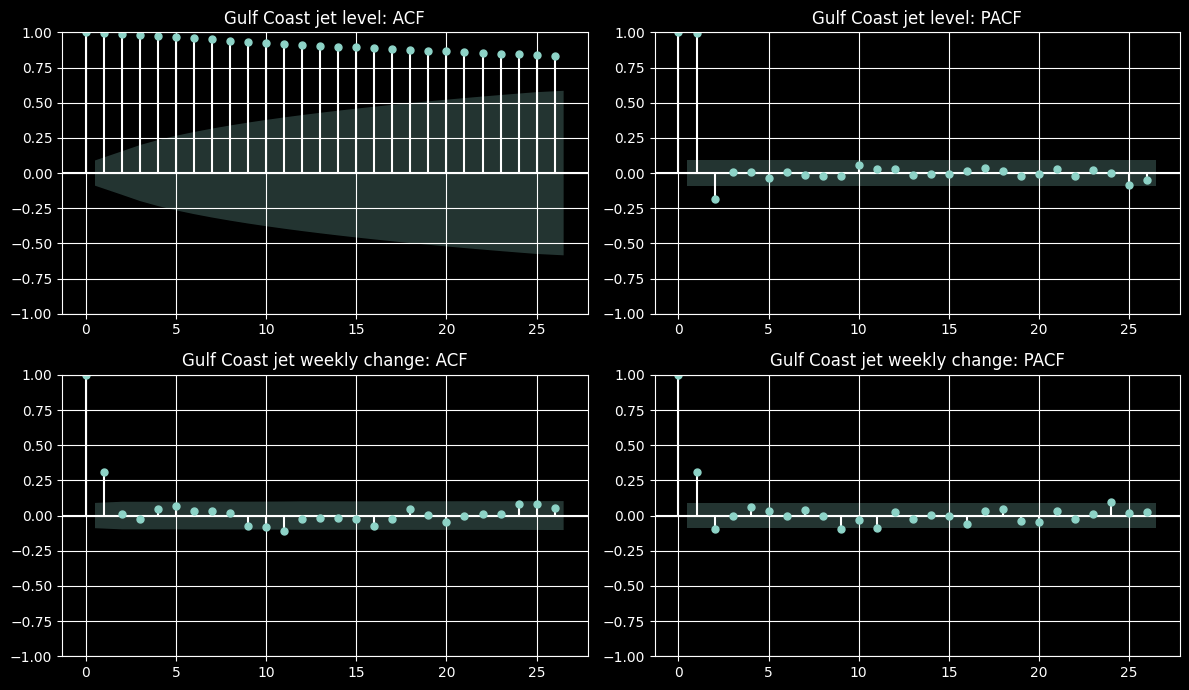

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
plot_acf(PRE['GC_JET'].dropna(), lags=26, ax=axes[0, 0], title='Gulf Coast jet level: ACF')
plot_pacf(PRE['GC_JET'].dropna(), lags=26, ax=axes[0, 1], method='ywm', title='Gulf Coast jet level: PACF')
plot_acf(CHANGES['GC_JET'].dropna(), lags=26, ax=axes[1, 0], title='Gulf Coast jet weekly change: ACF')
plot_pacf(CHANGES['GC_JET'].dropna(), lags=26, ax=axes[1, 1], method='ywm', title='Gulf Coast jet weekly change: PACF')
plt.tight_layout()
plt.show()

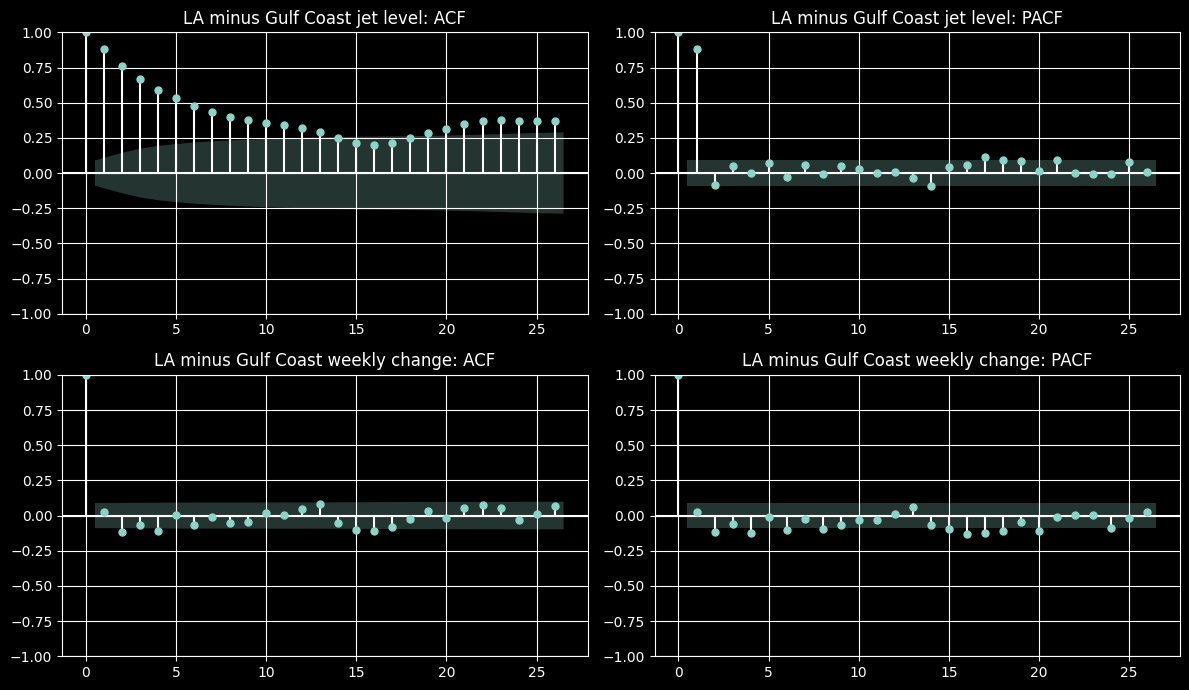

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
plot_acf(PRE['LA_GC_1'].dropna(), lags=26, ax=axes[0, 0], title='LA minus Gulf Coast jet level: ACF')
plot_pacf(PRE['LA_GC_1'].dropna(), lags=26, ax=axes[0, 1], method='ywm', title='LA minus Gulf Coast jet level: PACF')
plot_acf(CHANGES['LA_GC_1'].dropna(), lags=26, ax=axes[1, 0], title='LA minus Gulf Coast weekly change: ACF')
plot_pacf(CHANGES['LA_GC_1'].dropna(), lags=26, ax=axes[1, 1], method='ywm', title='LA minus Gulf Coast weekly change: PACF')
plt.tight_layout()
plt.show()

In [ ]:
# half-life and weekly move stored at full precision (raw) for the shortlist rules;
# the unmarked columns keep the rounded display values
MEMORY = pd.DataFrame(index=S.columns,
                      columns=['phi', 'half_life_weeks', 'pacf_lags_that_matter', 'typical_weekly_move', 'acf1_of_changes',
                               'half_life_weeks_raw', 'typical_weekly_move_raw'])
for name in S.columns:
    s = PRE[name].dropna()
    fit = sm.OLS(s.values[1:], sm.add_constant(s.values[:-1])).fit()
    phi = fit.params[1]
    if 0 < phi < 1:
        half_life = np.log(0.5) / np.log(phi)
    else:
        half_life = np.inf
    band = 1.96 / np.sqrt(len(s))
    p = pacf(s, nlags=8, method='ywm')[1:]
    lags_that_matter = int((np.abs(p) > band).sum())
    ch = s.diff().dropna()
    MEMORY.loc[name] = [round(phi, 3), round(half_life, 1), lags_that_matter, round(ch.std(), 2), round(ch.autocorr(1), 2),
                        half_life, ch.std()]
MEMORY.join(GROUP.rename('group'))


In [30]:
# Lag-one change correlation versus the 0.235 reference
MEMORY.loc[FLAT, ['acf1_of_changes']].assign(averaging_effect=0.235)

,acf1_of_changes,averaging_effect
LA_JET,0.34,0.235
GC_JET,0.31,0.235
NY_JET,0.34,0.235
HO,0.28,0.235
WTI,0.27,0.235
BRENT,0.28,0.235
GASOIL,0.32,0.235
NWE_JET,0.32,0.235
SING_KERO,0.32,0.235


In [31]:
PCA_SHARES = pd.DataFrame(columns=['whole_curve', 'front_vs_back', 'middle_vs_ends', 'corr_M1_M2_changes'])
PCA_LOADINGS = {}
for tag, root, kind in CURVES:
    cols = [f'{root}{n} {kind}' for n in range(1, 7)]
    X = CG.loc[:PRE_COVID_END, cols].diff().dropna()
    values, vectors = np.linalg.eigh(np.cov(X.values.T))
    order = np.argsort(values)[::-1]
    values = values[order]
    vectors = vectors[:, order]
    shares = values / values.sum()
    PCA_SHARES.loc[tag] = [shares[0], shares[1], shares[2], X.iloc[:, 0].corr(X.iloc[:, 1])]
    PCA_LOADINGS[tag] = vectors[:, :3]
PCA_SHARES.astype(float).round(4)

,whole_curve,front_vs_back,middle_vs_ends,corr_M1_M2_changes
LA_JET,0.9792,0.0122,0.0040,0.9709
GC_JET,0.9870,0.0077,0.0027,0.9901
NY_JET,0.9883,0.0074,0.0024,0.9851
HO,0.9795,0.0174,0.0021,0.9650
WTI,0.9918,0.0075,0.0005,0.9965
BRENT,0.9945,0.0050,0.0005,0.9948
GASOIL,0.9929,0.0056,0.0008,0.9938
NWE_JET,0.9948,0.0041,0.0006,0.9958
SING_KERO,0.9952,0.0036,0.0005,0.9967


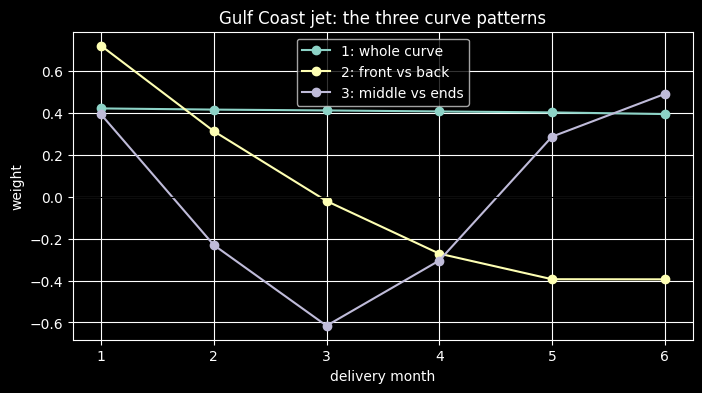

In [32]:
L = PCA_LOADINGS['GC_JET']
fig, ax = plt.subplots(figsize=(8, 4))
for i, label in enumerate(['1: whole curve', '2: front vs back', '3: middle vs ends']):
    sign = np.sign(L[0, i]) if L[0, i] != 0 else 1
    ax.plot(range(1, 7), sign * L[:, i], marker='o', label=label)
ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel('delivery month')
ax.set_ylabel('weight')
ax.set_title('Gulf Coast jet: the three curve patterns')
ax.legend()
plt.show()

In [33]:
JET_VS_HO = pd.DataFrame(columns=['corr_with_HO_M1M2', 'corr_with_HO_M2M3'])
HO_M2M3_CHANGE = CHANGES['HO_M2M3']
for tag in ['LA_JET', 'GC_JET', 'NY_JET']:
    JET_VS_HO.loc[f'{tag}_M1M2'] = [CHANGES[f'{tag}_M1M2'].corr(CHANGES['HO_M1M2']), CHANGES[f'{tag}_M1M2'].corr(HO_M2M3_CHANGE)]
JET_VS_HO.astype(float).round(2)

,corr_with_HO_M1M2,corr_with_HO_M2M3
LA_JET_M1M2,0.02,0.06
GC_JET_M1M2,0.17,0.22
NY_JET_M1M2,0.25,0.36


## 9. Redundant series

**Method.** Removes series that are arithmetic combinations of others, then groups the
rest by how they move together, then scores how far each one can be rebuilt from the others.

**Reason.** Some of the 55 series are the same information written twice. If the
difference between month 1 and month 2 is on the list, and so is month 2 minus month 3, then month 1
minus month 3 is just those two added together and adds nothing. Counting all three would overstate diversification because the positions reduce to the same arithmetic exposure.

Series are grouped by correlation, which measures whether two series tend to move up and down
together, from 1 for lockstep to 0 for unrelated. The rebuild score has a formal name, the
**variance inflation factor**, and it answers a different question: how much of this one
series could be reconstructed from all the others combined. Above 10 is the usual warning line, and
it means the series is close to reproducible from the others.

**Result.** 16 of the 55 series are arithmetic identities of others and are removed.
The groups form by geography, as you would expect: the Los Angeles spreads cluster together, and
the Gulf Coast spreads cluster together.

**Interpretation.** From each group only one name survives: the one that moves most, because it offers
the most movement for the same underlying exposure. The groups forming by geography rather than at random is
a sign the grouping reflects something real, because spreads sharing a delivery location
share the same supply conditions.

In [34]:
IDENTITY = pd.DataFrame(columns=['largest_gap_cents'])
IDENTITY.loc['LA_NY_1 = LA_GC_1 - NY_GC_1'] = (S['LA_NY_1'] - (S['LA_GC_1'] - S['NY_GC_1'])).abs().max()
IDENTITY.loc['NY_NWE_1 = NY_GC_1 - NWE_GC_1'] = (S['NY_NWE_1'] - (S['NY_GC_1'] - S['NWE_GC_1'])).abs().max()
IDENTITY.loc['LA_SING_1 = LA_GC_1 - SING_GC_1'] = (S['LA_SING_1'] - (S['LA_GC_1'] - S['SING_GC_1'])).abs().max()
IDENTITY.loc['LA_GC_2 = LA_GC_1 - LA_JET_M1M2 + GC_JET_M1M2'] = (S['LA_GC_2'] - (S['LA_GC_1'] - S['LA_JET_M1M2'] + S['GC_JET_M1M2'])).abs().max()
IDENTITY.loc['NY_GC_2 = NY_GC_1 - NY_JET_M1M2 + GC_JET_M1M2'] = (S['NY_GC_2'] - (S['NY_GC_1'] - S['NY_JET_M1M2'] + S['GC_JET_M1M2'])).abs().max()
IDENTITY.loc['GC_JET_WTI = GC_JET_BRENT + BRENT_WTI'] = (S['GC_JET_WTI'] - (S['GC_JET_BRENT'] + S['BRENT_WTI'])).abs().max()
IDENTITY.loc['HO_WTI = HO_BRENT + BRENT_WTI'] = (S['HO_WTI'] - (S['HO_BRENT'] + S['BRENT_WTI'])).abs().max()
for tag, root, kind in CURVES:
    IDENTITY.loc[f'{tag}_M1M3 = {tag}_M1M2 + {tag}_M2M3'] = (S[f'{tag}_M1M3'] - (S[f'{tag}_M1M2'] + S[f'{tag}_M2M3'])).abs().max()
IDENTITY.astype(float).round(6)

                                                  largest_gap_cents
LA_NY_1 = LA_GC_1 - NY_GC_1                                     0.0
NY_NWE_1 = NY_GC_1 - NWE_GC_1                                   0.0
LA_SING_1 = LA_GC_1 - SING_GC_1                                 0.0
LA_GC_2 = LA_GC_1 - LA_JET_M1M2 + GC_JET_M1M2                   0.0
NY_GC_2 = NY_GC_1 - NY_JET_M1M2 + GC_JET_M1M2                   0.0
GC_JET_WTI = GC_JET_BRENT + BRENT_WTI                           0.0
HO_WTI = HO_BRENT + BRENT_WTI                                   0.0
LA_JET_M1M3 = LA_JET_M1M2 + LA_JET_M2M3                         0.0
GC_JET_M1M3 = GC_JET_M1M2 + GC_JET_M2M3                         0.0
NY_JET_M1M3 = NY_JET_M1M2 + NY_JET_M2M3                         0.0
HO_M1M3 = HO_M1M2 + HO_M2M3                                     0.0
WTI_M1M3 = WTI_M1M2 + WTI_M2M3                                  0.0
BRENT_M1M3 = BRENT_M1M2 + BRENT_M2M3                            0.0
GASOIL_M1M3 = GASOIL_M1M2 + GASOIL_M2M3         

In [35]:
# Remove arithmetic identities
REBUILT = ['LA_NY_1', 'NY_NWE_1', 'LA_SING_1', 'LA_GC_2', 'NY_GC_2', 'GC_JET_WTI', 'HO_WTI'] + [f'{tag}_M1M3' for tag, root, kind in CURVES]
CANDIDATES = [name for name in S.columns if GROUP[name] != 'flat' and name not in REBUILT]
print(len(CANDIDATES), 'candidates:', CANDIDATES)

30 candidates: ['LA_GC_1', 'NY_GC_1', 'NWE_GC_1', 'SING_GC_1', 'LA_JET_M1M2', 'LA_JET_M2M3', 'GC_JET_M1M2', 'GC_JET_M2M3', 'NY_JET_M1M2', 'NY_JET_M2M3', 'HO_M1M2', 'HO_M2M3', 'WTI_M1M2', 'WTI_M2M3', 'BRENT_M1M2', 'BRENT_M2M3', 'GASOIL_M1M2', 'GASOIL_M2M3', 'NWE_JET_M1M2', 'NWE_JET_M2M3', 'SING_KERO_M1M2', 'SING_KERO_M2M3', 'LA_DIFF_1', 'GC_DIFF_1', 'NY_DIFF_1', 'GC_JET_BRENT', 'HO_BRENT', 'BRENT_WTI', 'HO_GASOIL', 'NWE_JET_GASOIL']


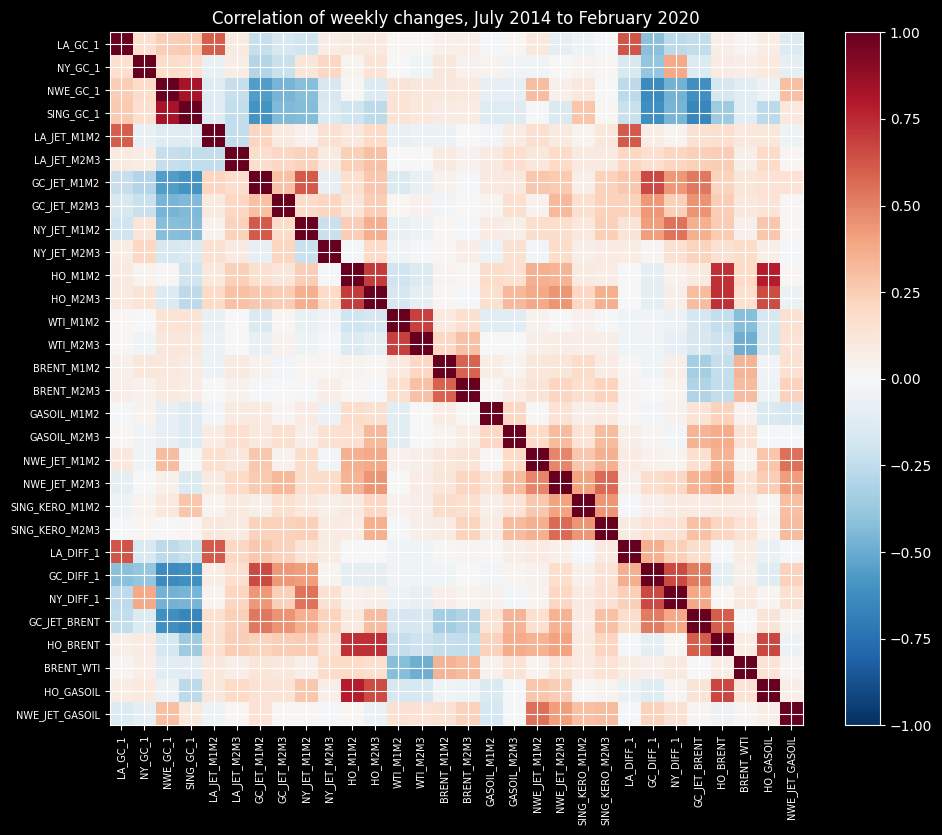

In [36]:
CORR = CHANGES.loc[NY_CLEAN_START:, CANDIDATES].corr()
fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(CORR.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(CANDIDATES)))
ax.set_xticklabels(CANDIDATES, rotation=90, fontsize=7)
ax.set_yticks(range(len(CANDIDATES)))
ax.set_yticklabels(CANDIDATES, fontsize=7)
plt.colorbar(im, ax=ax, fraction=0.046)
ax.set_title('Correlation of weekly changes, July 2014 to February 2020')
plt.show()

In [37]:
# Correlation clusters: mean absolute correlation above 0.5
DIST = 1 - CORR.abs()
Z = linkage(squareform(DIST.values, checks=False), method='average')
CLUSTER = pd.Series(fcluster(Z, t=0.5, criterion='distance'), index=CANDIDATES, name='cluster')
for c in sorted(CLUSTER.unique()):
    members = CLUSTER.index[CLUSTER == c].tolist()
    if len(members) > 1:
        print('cluster', c, ':', members)
print('spreads alone in their own cluster:', CLUSTER.index[CLUSTER.map(CLUSTER.value_counts()) == 1].tolist())

cluster 1 : ['BRENT_M1M2', 'BRENT_M2M3']
cluster 2 : ['WTI_M1M2', 'WTI_M2M3']
cluster 4 : ['NWE_JET_M1M2', 'NWE_JET_GASOIL']
cluster 5 : ['NWE_JET_M2M3', 'SING_KERO_M2M3']
cluster 7 : ['HO_M1M2', 'HO_M2M3', 'HO_BRENT', 'HO_GASOIL']
cluster 11 : ['LA_GC_1', 'LA_JET_M1M2', 'LA_DIFF_1']
cluster 12 : ['GC_JET_M1M2', 'NY_JET_M1M2']
cluster 13 : ['NWE_GC_1', 'SING_GC_1', 'GC_DIFF_1', 'NY_DIFF_1', 'GC_JET_BRENT']
spreads alone in their own cluster: ['NY_GC_1', 'LA_JET_M2M3', 'GC_JET_M2M3', 'NY_JET_M2M3', 'GASOIL_M1M2', 'GASOIL_M2M3', 'SING_KERO_M1M2', 'BRENT_WTI']


In [38]:
X = CHANGES.loc[NY_CLEAN_START:, CANDIDATES].dropna()
XC = sm.add_constant(X)
VIF = pd.Series([variance_inflation_factor(XC.values, i) for i in range(1, XC.shape[1])], index=CANDIDATES, name='vif')
VIF.sort_values(ascending=False).round(1)

HO_BRENT          35.7
GC_DIFF_1         31.1
GC_JET_BRENT      21.6
NY_DIFF_1         15.9
HO_M1M2           14.6
LA_GC_1           13.5
NWE_GC_1          11.4
NY_GC_1           10.2
SING_GC_1          9.6
LA_DIFF_1          8.6
HO_GASOIL          6.1
HO_M2M3            4.8
LA_JET_M1M2        4.6
GC_JET_M1M2        3.7
NWE_JET_M1M2       3.6
NY_JET_M1M2        3.0
WTI_M2M3           3.0
NWE_JET_M2M3       2.9
NWE_JET_GASOIL     2.8
BRENT_WTI          2.5
LA_JET_M2M3        2.5
SING_KERO_M1M2     2.3
SING_KERO_M2M3     2.3
BRENT_M2M3         2.2
WTI_M1M2           2.1
BRENT_M1M2         2.0
GC_JET_M2M3        1.8
NY_JET_M2M3        1.8
GASOIL_M1M2        1.8
GASOIL_M2M3        1.7
Name: vif, dtype: float64

In [39]:
# VIF with an identity included
X2 = CHANGES.loc[NY_CLEAN_START:, CANDIDATES + ['GC_JET_M1M3']].dropna()
XC2 = sm.add_constant(X2)
print('VIF of GC_JET_M1M3 with M1M2 and M2M3 present:', variance_inflation_factor(XC2.values, XC2.shape[1] - 1))

VIF of GC_JET_M1M3 with M1M2 and M2M3 present: inf


## 10. Lead-lag test

**Method.** Checks whether last week's move in one series helps predict this week's move
in another, beyond what the second series' own history already tells you.

**Reason.** Two series moving together in the same week is not tradable: by the time you see
one move, the other has already moved. What would be tradable is a lead, where one series moves
first and the other follows a week later. The test for this is named after the economist Clive
Granger, and it guards one thing: it asks whether series X adds predictive power **after**
series Y's own past has already been used. Without that, a series that predicts itself would
look like it was being predicted by everything correlated with it.

**Result.** The series move together within the same week, and no lead survives the test. All
of the p-values sit above 0.0023, which after correcting for the number of pairs tested is no
evidence of a lead at all.

**Interpretation.** The lead-lag screen retains zero relationships. The regional markets appear to absorb shared information within the same week, so later prediction work uses physical variables rather than price-to-price lead effects.

In [40]:
PAIRS = [('NWE_JET', 'NY_JET'), ('SING_KERO', 'LA_JET'), ('GC_JET', 'NY_JET'), ('GC_JET', 'LA_JET'),
         ('HO', 'GC_JET'), ('BRENT', 'GC_JET'), ('WTI', 'GC_JET'), ('BRENT', 'WTI'),
         ('NWE_GC_1', 'NY_GC_1'), ('SING_GC_1', 'LA_GC_1'), ('HO_M1M2', 'GC_JET_M1M2')]
XCORR = pd.DataFrame(columns=['x_2w_after_y', 'x_1w_after_y', 'same_week', 'x_1w_before_y', 'x_2w_before_y'])
for x, y in PAIRS:
    dx = CHANGES.loc[NY_CLEAN_START:, x]
    dy = CHANGES.loc[NY_CLEAN_START:, y]
    XCORR.loc[f'{x} -> {y}'] = [dy.corr(dx.shift(k)) for k in [-2, -1, 0, 1, 2]]
XCORR.astype(float).round(2)

,x_2w_after_y,x_1w_after_y,same_week,x_1w_before_y,x_2w_before_y
NWE_JET -> NY_JET,0.04,0.35,0.96,0.35,0.05
SING_KERO -> LA_JET,0.05,0.34,0.94,0.38,0.07
GC_JET -> NY_JET,0.02,0.33,0.99,0.35,0.04
GC_JET -> LA_JET,0.02,0.34,0.96,0.37,0.05
HO -> GC_JET,0.05,0.34,0.92,0.34,0.03
BRENT -> GC_JET,0.06,0.32,0.92,0.35,0.05
WTI -> GC_JET,0.04,0.29,0.86,0.36,0.06
BRENT -> WTI,0.08,0.33,0.93,0.30,0.07
NWE_GC_1 -> NY_GC_1,-0.06,-0.08,0.18,0.02,-0.05
SING_GC_1 -> LA_GC_1,-0.03,-0.09,0.26,-0.03,-0.05


In [41]:
GRANGER = pd.DataFrame(columns=['p_x_leads_y', 'p_y_leads_x'])
for x, y in PAIRS:
    both = CHANGES.loc[NY_CLEAN_START:, [y, x]].dropna()
    p_xy = grangercausalitytests(both[[y, x]], maxlag=[2], verbose=False)[2][0]['ssr_ftest'][1]   # x leads y
    p_yx = grangercausalitytests(both[[x, y]], maxlag=[2], verbose=False)[2][0]['ssr_ftest'][1]   # y leads x
    GRANGER.loc[f'{x} -> {y}'] = [p_xy, p_yx]
GRANGER.astype(float).round(3)

,p_x_leads_y,p_y_leads_x
NWE_JET -> NY_JET,0.120,0.797
SING_KERO -> LA_JET,0.108,0.812
GC_JET -> NY_JET,0.124,0.772
GC_JET -> LA_JET,0.280,0.788
HO -> GC_JET,0.408,0.022
BRENT -> GC_JET,0.239,0.653
WTI -> GC_JET,0.090,0.410
BRENT -> WTI,0.929,0.389
NWE_GC_1 -> NY_GC_1,0.713,0.478
SING_GC_1 -> LA_GC_1,0.698,0.372


## 11. Seasonality

**Method.** Gives each calendar month its own average and measures how much of a
series' movement that repeating annual pattern accounts for.

**Reason.** A repeating annual pattern is the simplest thing that can masquerade as a
forecast. If a model is only rediscovering that December differs from July, it carries no
information a trader does not already have. Month-by-month averages are the plainest way to measure
that. The reported share of movement explained is the **R-squared**: 0.39 means the calendar accounts
for 39 percent of the movement and the other 61 percent comes from elsewhere. The accompanying
p-value uses a correction, named after Newey and West, that stops overlapping weeks from making the
pattern look more certain than it is.

**Result.** The Gulf Coast jet fuel calendar spread is the most seasonal series in the set, at
39 percent. Los Angeles minus Gulf Coast is the opposite: the calendar accounts for about 10 percent
and the p-value is 0.226, well short of the 0.05 needed to call it real. Dropping 2017 from the data
leaves the Gulf Coast pattern intact, so it is not an artifact of one year.

**Interpretation.** Jet fuel and heating oil demand rise and fall with the seasons, so a spread
between two delivery months in the same region inherits that pattern. A spread between two different
regions subtracts two places with the same seasonal demand, and most of the season cancels. That is
why the Los Angeles spread shows a calendar effect of 10 percent at p 0.226, and it is the reason its forecast later
uses inventories instead of a calendar term: for that spread the calendar holds nothing and
inventories hold something. Month is treated as an association throughout, not as a cause.

In [42]:
SEASON = pd.DataFrame(index=CANDIDATES, columns=['r_squared_month', 'p_month'])
for name in CANDIDATES:
    d = PRE[[name]].dropna().rename(columns={name: 'y'})
    d['month'] = d.index.month
    fit = smf.ols('y ~ C(month)', data=d).fit(cov_type='HAC', cov_kwds={'maxlags': 8})
    R = np.eye(len(fit.params))[1:]
    SEASON.loc[name] = [round(fit.rsquared, 2), round(float(fit.f_test(R).pvalue), 3)]
SEASON.sort_values('r_squared_month', ascending=False)

               r_squared_month p_month
GC_JET_M1M2               0.39     0.0
GC_JET_M2M3               0.37     0.0
NWE_GC_1                  0.22     0.0
SING_GC_1                  0.2   0.001
HO_M2M3                   0.19     0.0
HO_BRENT                  0.18   0.003
GASOIL_M1M2               0.14   0.011
WTI_M1M2                  0.14   0.458
NY_GC_1                   0.13   0.349
GASOIL_M2M3               0.13   0.176
LA_JET_M2M3               0.13   0.002
NY_JET_M2M3               0.13   0.198
HO_M1M2                   0.13    0.04
WTI_M2M3                  0.11   0.669
LA_GC_1                    0.1   0.226
NWE_JET_M2M3              0.09   0.321
NY_DIFF_1                 0.09   0.743
GC_JET_BRENT              0.08   0.597
NY_JET_M1M2               0.07   0.536
SING_KERO_M2M3            0.07    0.69
GC_DIFF_1                 0.07   0.553
HO_GASOIL                 0.06   0.635
LA_JET_M1M2               0.06   0.315
SING_KERO_M1M2            0.06   0.545
LA_DIFF_1                

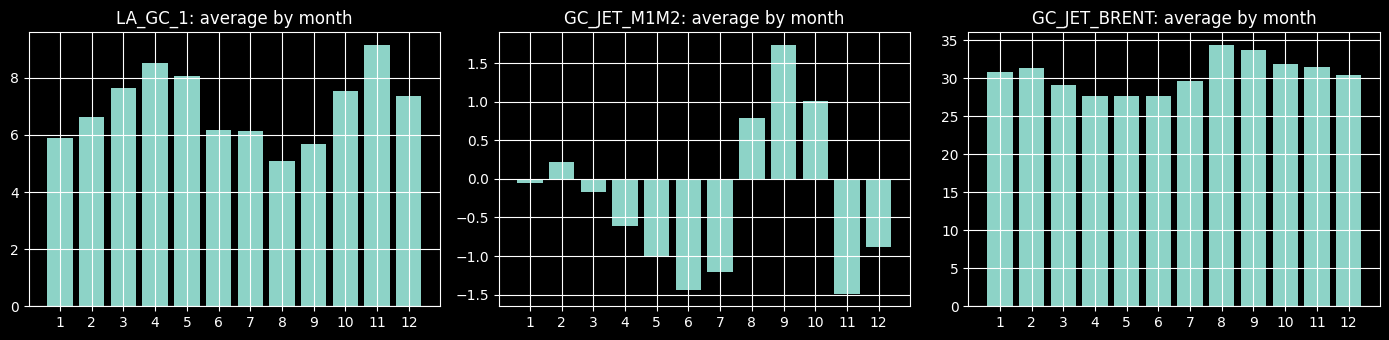

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for ax, name in zip(axes, ['LA_GC_1', 'GC_JET_M1M2', 'GC_JET_BRENT']):
    by_month = PRE[name].groupby(PRE.index.month).mean()
    ax.bar(by_month.index, by_month.values)
    ax.set_title(f'{name}: average by month')
    ax.set_xticks(range(1, 13))
plt.tight_layout()
plt.show()

In [44]:
# Seasonality sensitivity check excluding 2017
d = PRE[['GC_JET_M1M2']].rename(columns={'GC_JET_M1M2': 'y'}).dropna()
d = d[d.index.year != 2017]
d['month'] = d.index.month
fit = smf.ols('y ~ C(month)', data=d).fit(cov_type='HAC', cov_kwds={'maxlags': 8})
print('without 2017: R-squared', round(fit.rsquared, 2), '| p-value', round(float(fit.f_test(np.eye(len(fit.params))[1:]).pvalue), 4))
d.groupby('month')['y'].mean().round(2).to_frame('GC_JET_M1M2 average without 2017').T

without 2017: R-squared 0.38 | p-value 0.0


month,1,2,3,4,5,6,7,8,9,10,11,12
GC_JET_M1M2 average without 2017,0.06,0.25,-0.09,-0.59,-0.98,-1.42,-1.3,0.76,1.34,1.03,-1.59,-1.06


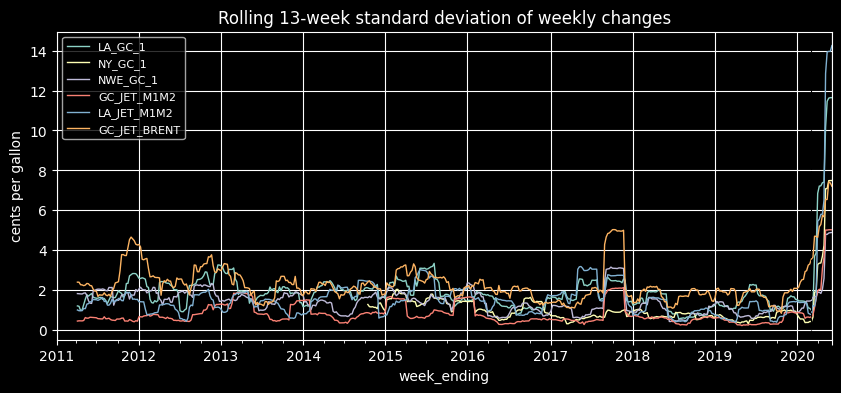

In [45]:
VOL_SERIES = ['LA_GC_1', 'NY_GC_1', 'NWE_GC_1', 'GC_JET_M1M2', 'LA_JET_M1M2', 'GC_JET_BRENT']
ROLL_SD = S[VOL_SERIES].diff().rolling(13).std()
fig, ax = plt.subplots()
for name in VOL_SERIES:
    ROLL_SD[name].plot(ax=ax, label=name, lw=1)
ax.axvline(pd.Timestamp(COVID_START), color='black', ls='--', lw=0.8)
ax.set_ylabel('cents per gallon')
ax.set_title('Rolling 13-week standard deviation of weekly changes')
ax.legend(fontsize=8)
plt.show()

In [46]:
PERIODS = []
for name in VOL_SERIES:
    flag = ROLL_SD[name] > 3 * ROLL_SD[name].loc[:PRE_COVID_END].median()
    start = None
    prev = None
    for week, is_high in flag.items():
        if is_high and start is None:
            start = week
        if not is_high and start is not None:
            PERIODS.append([name, start.date(), prev.date()])
            start = None
        prev = week
    if start is not None:
        PERIODS.append([name, start.date(), prev.date()])
pd.DataFrame(PERIODS, columns=['series', 'from', 'to'])

,series,from,to
0,LA_GC_1,2020-04-03,2020-06-05
1,NY_GC_1,2020-04-03,2020-06-05
2,NWE_GC_1,2020-05-08,2020-06-05
3,GC_JET_M1M2,2013-03-01,2013-03-01
4,GC_JET_M1M2,2013-03-15,2013-04-26
5,GC_JET_M1M2,2017-09-08,2017-11-24
6,GC_JET_M1M2,2020-04-03,2020-06-05
7,LA_JET_M1M2,2020-04-03,2020-06-05
8,GC_JET_BRENT,2020-05-08,2020-06-05


## 13. The scorecard

**Method.** Applies the four screens in order and records, for each series, whether it
passed or failed each one.

**The four screens.** Comes back to a normal level, with a p-value below 0.05 on the first test.
Halves a move within 8 weeks. Moves at least 1 cent per gallon in a typical week. And, among the
series in its correlation group that already passed the first three, moves the most.

**Reason.** Each screen is cheaper to apply than the next and removes the most candidates,
so the expensive comparisons only run on series that already qualify. The order does not change the
survivors, only the work.

**Result.** Four survivors: LA_GC_1, which halves a move in 5.8 weeks and moves 1.83 cents a
week; SING_GC_1 at 5.0 weeks and 1.57 cents; LA_JET_M2M3 at 2.0 weeks and 1.17 cents; and HO_BRENT
at 7.7 weeks and 3.01 cents. NY_GC_1 failed on move size at 0.99 cents, one hundredth of a cent
below the threshold.

**Interpretation.** NY_GC_1 missing by 0.01 cents shows that the thresholds affect the shortlist. A different cutoff would produce a different set of names. Notebook 03 also reports a narrower West Coast book selected after viewing the trading results. The four-name shortlist uses data through February 2020, so both sets are in-sample selections.

In [ ]:
SCORE = STAT.join(MEMORY).join(SEASON).join(CLUSTER).join(VIF)
SCORE['rebuilt'] = [name in REBUILT for name in SCORE.index]

# the four rules read the full-precision raw columns; rounding is display only
SCORE['rule_1_comes_back'] = SCORE['adf_p_raw'].astype(float) < 0.05
SCORE['rule_2_half_life'] = SCORE['half_life_weeks_raw'].astype(float) <= 8
SCORE['rule_3_moves_1c'] = SCORE['typical_weekly_move_raw'].astype(float) >= 1.0
PASS_1_TO_3 = SCORE['rule_1_comes_back'] & SCORE['rule_2_half_life'] & SCORE['rule_3_moves_1c']
SCORE['rule_4_best_in_cluster'] = False
for c in CLUSTER.unique():
    members = [m for m in CLUSTER.index[CLUSTER == c] if PASS_1_TO_3[m]]
    if len(members) > 0:
        best = SCORE.loc[members, 'typical_weekly_move_raw'].astype(float).idxmax()
        SCORE.loc[best, 'rule_4_best_in_cluster'] = True

SCORE['shortlist'] = (SCORE['group'] != 'flat') & PASS_1_TO_3 & SCORE['rule_4_best_in_cluster']
SCORE.loc[CANDIDATES, ['group', 'verdict', 'half_life_weeks', 'typical_weekly_move', 'cluster',
                       'rule_1_comes_back', 'rule_2_half_life', 'rule_3_moves_1c', 'rule_4_best_in_cluster', 'shortlist']].sort_values(
    ['shortlist', 'typical_weekly_move'], ascending=False)


In [48]:
SHORTLIST = SCORE.index[SCORE['shortlist']].tolist()
print('shortlist:', SHORTLIST)
SCORE.loc[SHORTLIST, ['group', 'first_week', 'weeks', 'adf_p', 'kpss_p', 'verdict', 'half_life_weeks', 'typical_weekly_move', 'r_squared_month', 'p_month', 'vif']]

shortlist: ['LA_GC_1', 'SING_GC_1', 'LA_JET_M2M3', 'HO_BRENT']


,group,first_week,weeks,adf_p,kpss_p,verdict,half_life_weeks,typical_weekly_move,r_squared_month,p_month,vif
LA_GC_1,regional,2011-01-07,478,0.0,0.01,shifting level,5.8,1.83,0.1,0.226,13.461761
SING_GC_1,foreign,2011-01-07,478,0.0,0.014,shifting level,5.0,1.57,0.2,0.001,9.598836
LA_JET_M2M3,time,2011-01-07,478,0.0,0.1,fixed level,2.0,1.17,0.13,0.002,2.456642
HO_BRENT,crack,2011-01-07,478,0.008,0.1,fixed level,7.7,3.01,0.18,0.003,35.655280


In [1]:
# Save cleaned prices and the scorecard.
CLEAN = S.copy()
CLEAN['month_change_week'] = MONTH_CHANGE_WEEK
CLEAN['covid_week'] = COVID_WEEK
CLEAN.to_csv('../data/prices_clean.csv')
SCORE.index.name = 'series'
SCORE.to_csv('../results/price_eda_scorecard.csv')
print(CLEAN.shape, SCORE.shape)
print('analysis step ids owned here:', ANALYSIS_STEP_IDS)


(492, 57) (55, 21)
analysis step ids owned here: ['EDA_spreads', 'EDA_screen', 'EDA_timing']


## Summary

| Check | Result | Consequence |
| --- | --- | --- |
| Outright-price return to normal | No. The first test cannot reject the idea that they never return, with p-values up to 1.00, and half-lives run from 31 to 303 weeks | Trade spreads, never outright prices |
| Spread return speed | Yes for regional and calendar spreads, halving a move in 2 to 7 weeks on this sample | A one-week to four-week holding period is realistic |
| Seasonality | Present in Gulf Coast calendar spreads at 39 percent of movement; absent in Los Angeles minus Gulf Coast at p 0.226 | Use inventories, not a calendar term, for the Los Angeles spread |
| Lead-lag relationship | No. No lead survives the test | Predictive power has to come from physical data |
| Final shortlist | LA_GC_1, LA_JET_M2M3, SING_GC_1, HO_BRENT | These four go forward |

**Conclusion.** Everything above describes this sample. The test for a price
leading another is the only prediction test here, and it failed. The thresholds (five years,
eight weeks, one cent), the correlation groups and the shortlist were all judgment calls made on
data through February 2020, which is the same stretch the trading simulation later uses. So the
shortlist is a choice made with hindsight, and the results that follow should be read as measurements
on this sample instead of as a strategy proven in advance.